# 4.0 Modelling

Trains and tunes the four regression models from the project objectives. Each
model gets its own section below and all of them are scored with the same
`evaluate_model()` helper so Section 5 can compare them like for like.

**Shared Setup must be run first** â€” it rebuilds the leakage-safe train/test
split from Section 3 and defines `XX_train` / `XX_test` / `y_train` / `y_test`
that every model section uses.

## Shared Setup

Reproduces the Section 3.5 pipeline exactly as in `02_data_preparation.ipynb`:
clean → treat outliers → split 80:20 → *then* transform. `transform()` and the
preprocessor are fit on the training split only, so cityname's target
encoding, the one-hot encoder and the scaler never see test data.

In [2]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

from src.final_dataset_output import build_prepared_dataset, RAW_CSV_PATH
from src.data_transformation import transform, get_engineered_feature_lists, build_preprocessor

# notebooks/ runs with a different cwd than the repo root — adjust the relative path
RAW_CSV_PATH = "../" + RAW_CSV_PATH

prepared_df = build_prepared_dataset(raw_csv_path=RAW_CSV_PATH, verbose=False)

# Split BEFORE any transformation
X = prepared_df.drop(columns=["price"])
y = prepared_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_transformed = transform(X_train)
X_test_transformed = transform(X_test)

numeric, categorical, city = get_engineered_feature_lists(X_train_transformed)

# scale_numeric=True — required by the scale-sensitive models (Linear Regression, KNN).
# Tree-based sections may rebuild the preprocessor with scale_numeric=False.
preprocessor = build_preprocessor(numeric, categorical, city, scale_numeric=True)

# TargetEncoder (used for cityname) is supervised, so fit_transform needs y_train.
XX_train = preprocessor.fit_transform(X_train_transformed, y_train)
XX_test = preprocessor.transform(X_test_transformed)

print("Encoded train:", XX_train.shape)
print("Encoded test :", XX_test.shape)

Encoded train: (79075, 76)
Encoded test : (19769, 76)


---

## Linear Regression Baseline

Linear Regression is the baseline model. It estimates rent as a linear combination of the prepared property features. It uses the scaled feature matrix from Shared Setup and has no hyperparameters to tune, so it gives the other models a simple, interpretable performance benchmark.

In [3]:
from sklearn.linear_model import LinearRegression
from src.modelling import evaluate_model

linear_baseline = LinearRegression()
linear_baseline.fit(XX_train, y_train)

linear_baseline_metrics = evaluate_model(linear_baseline, XX_test, y_test)

print("Linear Regression baseline (held-out test set)")
print(f"RMSE : ${linear_baseline_metrics['rmse']:,.2f}")
print(f"MAE  : ${linear_baseline_metrics['mae']:,.2f}")
print(f"R2   : {linear_baseline_metrics['r2']:.4f}")

Linear Regression baseline (held-out test set)
RMSE : $515.78
MAE  : $287.08
R2   : 0.6217


**Figure: predicted vs actual price — Linear Regression baseline diagnostic.**
Each point is one held-out test listing. The red line is `y = x` (a perfect prediction). This establishes a visual benchmark for the KNN and Random Forest diagnostics below.

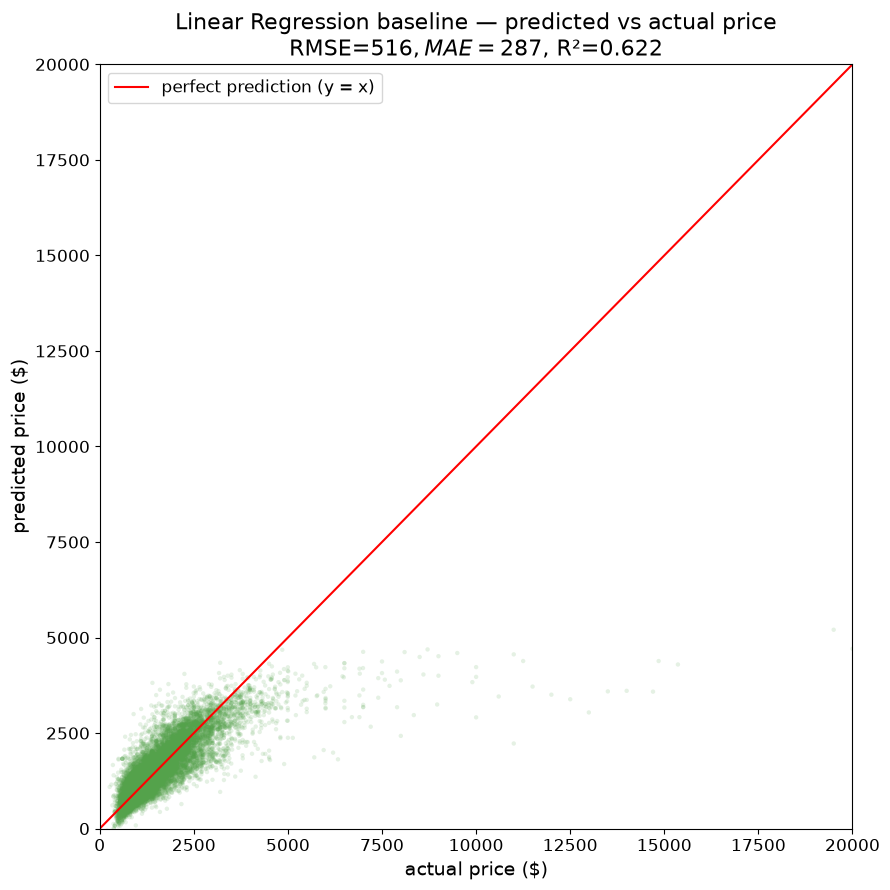

In [4]:
y_pred = linear_baseline_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#54A24B", edgecolors="none")
limits = [0, max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"Linear Regression baseline — predicted vs actual price\n"
             f"RMSE=${linear_baseline_metrics['rmse']:,.0f}, MAE=${linear_baseline_metrics['mae']:,.0f}, "
             f"R²={linear_baseline_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/linear_regression_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

---

## KNN Modelling

K-Nearest Neighbours predicts a listing's rent from the mean rent of its most
similar listings in feature space. It is scale-sensitive, so it uses the scaled
matrices built above. `n_neighbors` controls the bias/variance trade-off (small
k = low bias, high variance) and `weights` decides whether closer neighbours
count more, so both are tuned by 5-fold cross-validation.

In [4]:
from src.modelling import train_knn, evaluate_model, to_dense

# KNN has no sparse fast path â€” densify once here and reuse for training and scoring.
XX_train_knn = to_dense(XX_train)
XX_test_knn = to_dense(XX_test)

knn_grid = train_knn(XX_train_knn, y_train, cv=5)

print("Best parameters :", knn_grid.best_params_)
print(f"Best CV RMSE    : ${-knn_grid.best_score_:,.2f}")

Best parameters : {'n_neighbors': 7, 'weights': 'distance'}
Best CV RMSE    : $433.24


**Figure: k vs CV RMSE â€” evidence for hyperparameter search.**
Cross-validated RMSE for every `n_neighbors` tried, with `uniform` and
`distance` weighting shown separately. The minimum of the lower curve is the
selected model.

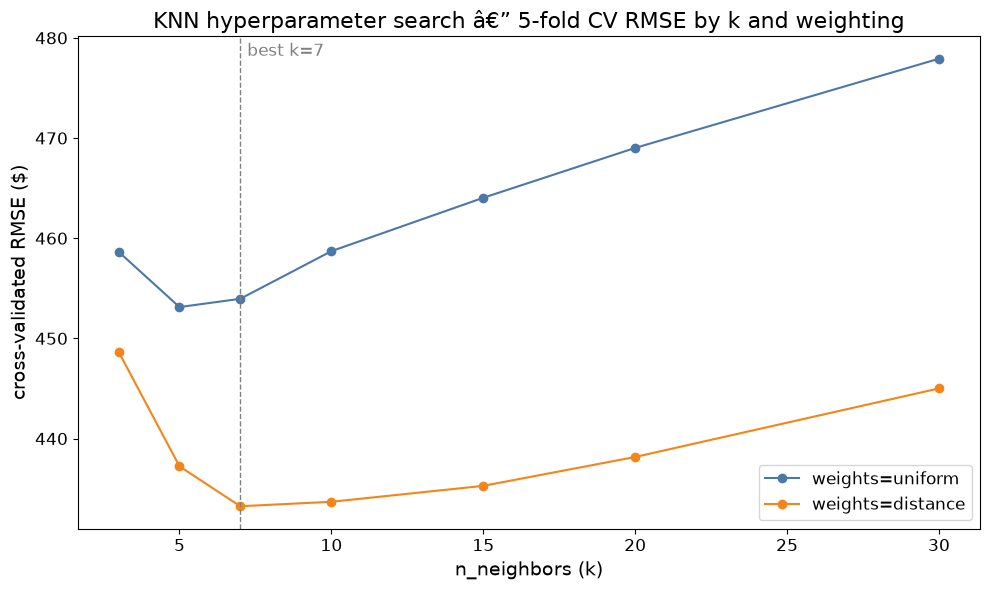

In [5]:
results = knn_grid.cv_results_
fig, ax = plt.subplots(figsize=(10, 6))

for weight, color in [("uniform", "#4C78A8"), ("distance", "#F58518")]:
    mask = np.array(results["param_weights"]) == weight
    ks = np.array(results["param_n_neighbors"])[mask]
    rmse = -np.array(results["mean_test_score"])[mask]
    order = np.argsort(ks)
    ax.plot(ks[order], rmse[order], marker="o", color=color, label=f"weights={weight}")

best_k = knn_grid.best_params_["n_neighbors"]
ax.axvline(best_k, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"best k={best_k}", xy=(best_k, ax.get_ylim()[1]),
            xytext=(5, -14), textcoords="offset points", fontsize=12, color="grey")

ax.set_xlabel("n_neighbors (k)", fontsize=14)
ax.set_ylabel("cross-validated RMSE ($)", fontsize=14)
ax.set_title("KNN hyperparameter search â€” 5-fold CV RMSE by k and weighting", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/knn_k_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [6]:
knn_metrics = evaluate_model(knn_grid.best_estimator_, XX_test_knn, y_test)

print(f"RMSE : ${knn_metrics['rmse']:,.2f}")
print(f"MAE  : ${knn_metrics['mae']:,.2f}")
print(f"R2   : {knn_metrics['r2']:.4f}")

RMSE : $459.19
MAE  : $222.10
R2   : 0.7002


**Figure: predicted vs actual price â€” KNN diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

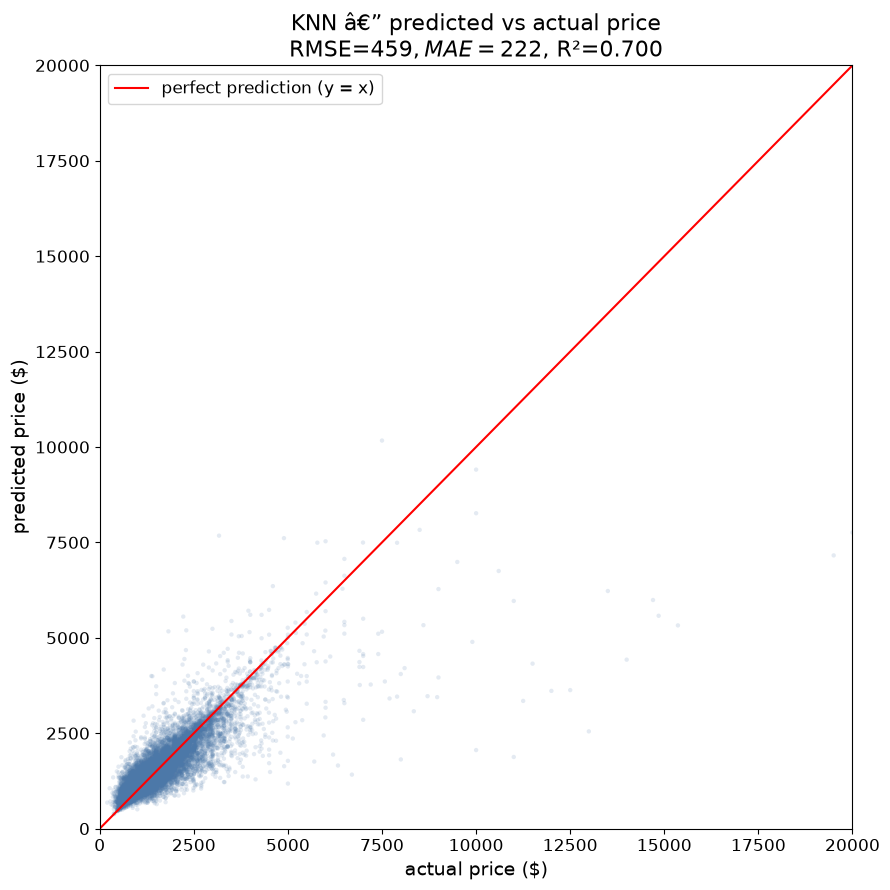

In [7]:
y_pred = knn_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C78A8", edgecolors="none")

limits = [0, max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"KNN â€” predicted vs actual price\n"
             f"RMSE=${knn_metrics['rmse']:,.0f}, MAE=${knn_metrics['mae']:,.0f}, "
             f"R\u00b2={knn_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/knn_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

---

## Random Forest Modelling

A Random Forest is an ensemble of decision trees, each trained on a bootstrap
sample of the data and a random subset of features; predictions are the average
over trees. The ensemble variance falls as more trees are added, and
`max_depth` / `min_samples_leaf` control how deep each tree can grow (the
bias/variance trade-off). Trees are scale-invariant, so this section rebuilds
the preprocessor with `scale_numeric=False` — the numeric features are left
unscaled but cityname is still target-encoded the same way as in Shared Setup.
All three hyperparameters are tuned together by 5-fold cross-validation.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Trees are scale-invariant, so this section uses the unscaled preprocessor
# (scale_numeric=False). cityname is still target-encoded like in Shared Setup.
rf_pipeline = Pipeline([
    ("preprocess", build_preprocessor(numeric, categorical, city, scale_numeric=False)),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rf_param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [10, 15, 20, None],
    "regressor__min_samples_leaf": [1, 2, 4],
}

# 36 combinations × 5 folds = 180 fits (~29 min on 12 cores)
rf_grid = GridSearchCV(
    rf_pipeline, param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1, verbose=1,
)
rf_grid.fit(X_train_transformed, y_train)

print("Best parameters :", rf_grid.best_params_)
print(f"Best CV RMSE    : ${-rf_grid.best_score_:,.2f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


KeyboardInterrupt: 

**Figure: hyperparameter search — evidence for tuning.**
Cross-validated RMSE for every `n_estimators`/`max_depth` combination, one panel
per `min_samples_leaf`. The deeper trees (darker blue) are consistently better,
and `max_depth=None` with 300 trees and `min_samples_leaf=1` is the selected
model.

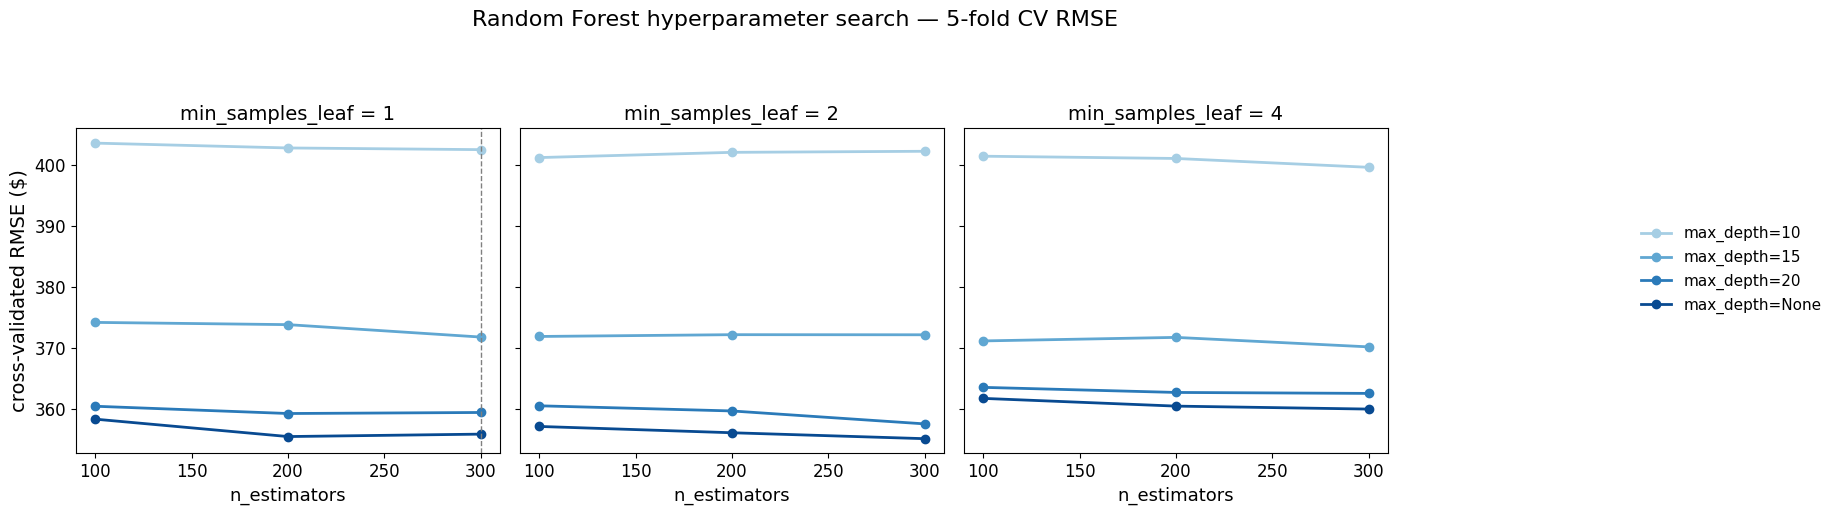

In [ ]:
results = rf_grid.cv_results_
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

leaf_values = [1, 2, 4]
depth_values = [10, 15, 20, None]
blues = plt.cm.Blues(np.linspace(0.35, 0.90, len(depth_values)))
depth_labels = {10: "max_depth=10", 15: "max_depth=15",
                20: "max_depth=20", None: "max_depth=None"}

handles, labels = [], []
for depth, color in zip(depth_values, blues):
    for leaf, ax in zip(leaf_values, axes):
        mask = (np.array(results["param_regressor__min_samples_leaf"]) == leaf) & \
               (np.array(results["param_regressor__max_depth"]) == depth)
        n_est = np.array(results["param_regressor__n_estimators"])[mask]
        rmse  = -np.array(results["mean_test_score"])[mask]
        order = np.argsort(n_est)
        line, = ax.plot(n_est[order], rmse[order], marker="o",
                       color=color, linewidth=2)
        if leaf == leaf_values[0]:
            handles.append(line)
            labels.append(depth_labels[depth])
    axes[0].set_ylabel("cross-validated RMSE ($)", fontsize=14)

for leaf, ax in zip(leaf_values, axes):
    ax.set_title(f"min_samples_leaf = {leaf}", fontsize=14)
    ax.set_xlabel("n_estimators", fontsize=13)
    ax.tick_params(axis="both", labelsize=12)

# Mark the best model in the left panel
best_depth = rf_grid.best_params_["regressor__max_depth"]
best_n     = rf_grid.best_params_["regressor__n_estimators"]
if best_depth is None:
    axes[0].axvline(best_n, color="grey", linestyle="--", linewidth=1)

fig.suptitle("Random Forest hyperparameter search — 5-fold CV RMSE", fontsize=16, y=1.02)
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
           fontsize=11, frameon=False)
fig.tight_layout(rect=[0, 0, 0.88, 0.93])
fig.savefig("../outputs/figures/rf_hyperparameter_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [ ]:
from src.modelling import evaluate_model

# X_test_transformed, not XX_test - the pipeline includes its own preprocessor
rf_metrics = evaluate_model(rf_grid.best_estimator_, X_test_transformed, y_test)

print(f"RMSE : ${rf_metrics['rmse']:,.2f}")
print(f"MAE  : ${rf_metrics['mae']:,.2f}")
print(f"R2   : {rf_metrics['r2']:.4f}")

RMSE : $380.75
MAE  : $176.22
R2   : 0.7939


**Figure: predicted vs actual price — Random Forest diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

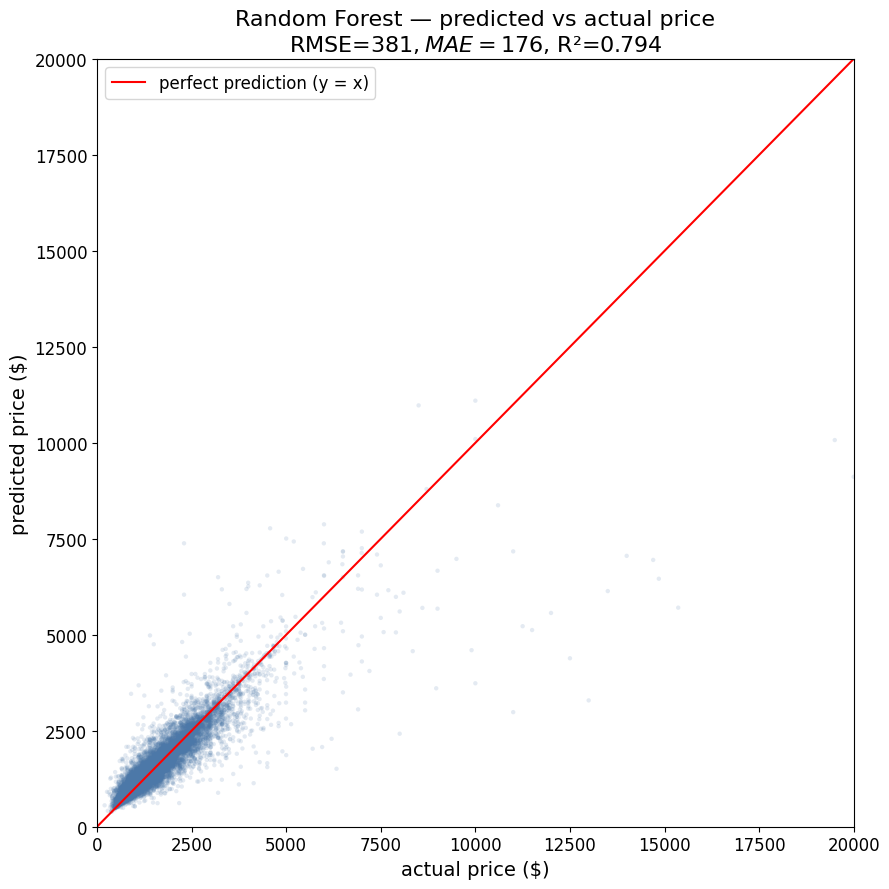

In [ ]:
y_pred = rf_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C78A8", edgecolors="none")

limits = [0, max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"Random Forest — predicted vs actual price\n"
             f"RMSE=${rf_metrics['rmse']:,.0f}, MAE=${rf_metrics['mae']:,.0f}, "
             f"R²={rf_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/rf_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

---

## Gradient Boosting Modelling (XGBoost)

Gradient Boosting builds trees sequentially, where each new tree corrects the
residual errors of the ensemble so far. Like Random Forest it is tree-based
and scale-invariant, so this section reuses the unscaled preprocessor
(`scale_numeric=False`) from the Random Forest section — cityname is still
target-encoded the same way as in Shared Setup. `n_estimators`, `max_depth`
and `learning_rate` are tuned together by 5-fold cross-validation: more/deeper
trees increase capacity, while a lower learning rate trades training speed for
generalisation.

In [7]:
from xgboost import XGBRegressor

# Trees are scale-invariant, so this section reuses the unscaled preprocessor
# (scale_numeric=False), same as Random Forest.
xgb_pipeline = Pipeline([
    ("preprocess", build_preprocessor(numeric, categorical, city, scale_numeric=False)),
    ("regressor", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
    )),
])

xgb_param_grid = {
    "regressor__n_estimators": [100, 300, 500],
    "regressor__max_depth": [3, 5, 7],
    "regressor__learning_rate": [0.01, 0.05, 0.1],
}

# 27 combinations x 5 folds = 135 fits
xgb_grid = GridSearchCV(
    xgb_pipeline, param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1, verbose=1,
)
xgb_grid.fit(X_train_transformed, y_train)

print("Best parameters :", xgb_grid.best_params_)
print(f"Best CV RMSE    : ${-xgb_grid.best_score_:,.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 500}
Best CV RMSE    : $354.76


**Figure: hyperparameter search — evidence for tuning.**
Cross-validated RMSE for every `n_estimators`/`learning_rate` combination, one
panel per `max_depth`. Lower learning rates (darker teal) generally need more
trees to reach the same RMSE; the selected model is marked with a dashed
line.

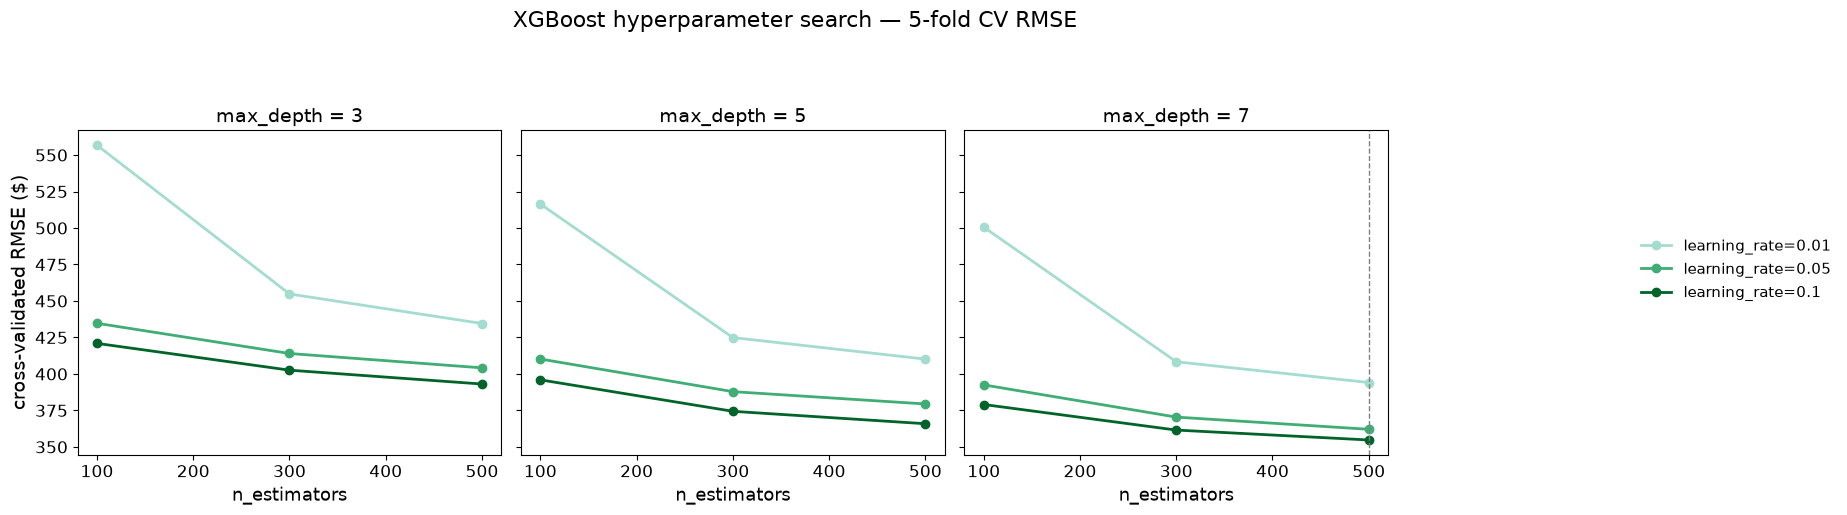

In [8]:
results = xgb_grid.cv_results_
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

depth_values = [3, 5, 7]
lr_values = [0.01, 0.05, 0.1]
teals = plt.cm.BuGn(np.linspace(0.35, 0.90, len(lr_values)))
lr_labels = {0.01: "learning_rate=0.01", 0.05: "learning_rate=0.05", 0.1: "learning_rate=0.1"}

handles, labels = [], []
for lr, color in zip(lr_values, teals):
    for depth, ax in zip(depth_values, axes):
        mask = (np.array(results["param_regressor__learning_rate"]) == lr) & \
               (np.array(results["param_regressor__max_depth"]) == depth)
        n_est = np.array(results["param_regressor__n_estimators"])[mask]
        rmse  = -np.array(results["mean_test_score"])[mask]
        order = np.argsort(n_est)
        line, = ax.plot(n_est[order], rmse[order], marker="o",
                       color=color, linewidth=2)
        if depth == depth_values[0]:
            handles.append(line)
            labels.append(lr_labels[lr])
    axes[0].set_ylabel("cross-validated RMSE ($)", fontsize=14)

for depth, ax in zip(depth_values, axes):
    ax.set_title(f"max_depth = {depth}", fontsize=14)
    ax.set_xlabel("n_estimators", fontsize=13)
    ax.tick_params(axis="both", labelsize=12)

# Mark the best model
best_depth_idx = depth_values.index(xgb_grid.best_params_["regressor__max_depth"])
best_n = xgb_grid.best_params_["regressor__n_estimators"]
axes[best_depth_idx].axvline(best_n, color="grey", linestyle="--", linewidth=1)

fig.suptitle("XGBoost hyperparameter search — 5-fold CV RMSE", fontsize=16, y=1.02)
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
           fontsize=11, frameon=False)
fig.tight_layout(rect=[0, 0, 0.88, 0.93])
fig.savefig("../outputs/figures/xgb_hyperparameter_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [9]:
from src.modelling import evaluate_model

# X_test_transformed, not XX_test - the pipeline includes its own preprocessor
xgb_metrics = evaluate_model(xgb_grid.best_estimator_, X_test_transformed, y_test)

print(f"RMSE : ${xgb_metrics['rmse']:,.2f}")
print(f"MAE  : ${xgb_metrics['mae']:,.2f}")
print(f"R2   : {xgb_metrics['r2']:.4f}")

RMSE : $379.43
MAE  : $189.36
R2   : 0.7953


c:\Users\User\Documents\GitHub\apartment_rental_price_prediction\rent_env\Lib\site-packages\xgboost\core.py:569: UserWarning: [04:21:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


**Figure: predicted vs actual price — XGBoost diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

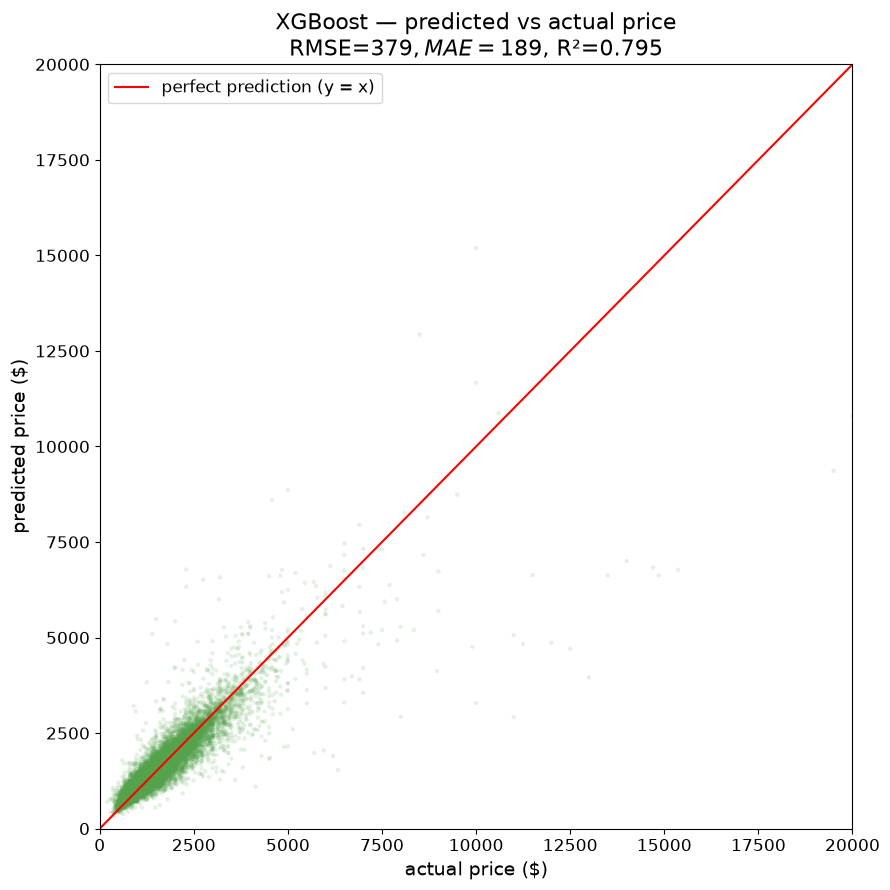

In [10]:
y_pred = xgb_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#54A24B", edgecolors="none")

limits = [0, max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"XGBoost — predicted vs actual price\n"
             f"RMSE=${xgb_metrics['rmse']:,.0f}, MAE=${xgb_metrics['mae']:,.0f}, "
             f"R\u00b2={xgb_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/xgb_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()